In [34]:
from shinka.utils import load_programs_to_df

path = "results/results_circle_async_small/"
programs_df, prompts_df = load_programs_to_df(path, include_prompts=True)

Total program rows: 35
Correct program rows: 24
Total cost: $0.53
Avg cost per program: $0.02
Total prompt rows: 7
Prompts in archive: 7


In [35]:
programs_df.head()

,id,code,language,parent_id,archive_inspiration_ids,top_k_inspiration_ids,generation,timestamp,complexity,embedding,...,temperature,max_output_tokens,llm_result,results_missing,safe_processing,meta_cost,meta_recommendations,meta_summary,meta_scratch_pad,total_cost
0,fb311356-29f1-4197-ac7d-30a6537a06bf,"# EVOLVE-BLOCK-START\n""""""Constructor-based cir...",python,NaN,[],[],0,2026-03-11 02:26:40.958653927,0.986,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
1,c1138656-06a0-457b-9c87-7103a5ac0864,"# EVOLVE-BLOCK-START\n""""""Constructor-based cir...",python,fb311356-29f1-4197-ac7d-30a6537a06bf,[],[],2,2026-03-11 02:26:54.111673117,0.735,[],...,1.0,32768.0,{'content': '<NAME> optimize_radii_slsqp </NAM...,False,True,NaN,NaN,NaN,NaN,0.006653
2,5e0baef3-4a82-407f-b4be-fa0500280933,"# EVOLVE-BLOCK-START\n""""""Constructor-based cir...",python,fb311356-29f1-4197-ac7d-30a6537a06bf,[],[],1,2026-03-11 02:26:54.234381914,0.559,[],...,0.0,32768.0,{'content': '<NAME> optimize_radii_sum_with_sl...,False,True,NaN,NaN,NaN,NaN,0.006650
3,847dc5c8-2624-48f4-b4cf-9e66523b1c9b,"# EVOLVE-BLOCK-START\n""""""Constructor-based cir...",python,fb311356-29f1-4197-ac7d-30a6537a06bf,[],[],3,2026-03-11 02:27:05.073811054,1.000,[],...,0.5,32768.0,{'content': '<NAME> iterative_radii_optimizati...,False,True,NaN,NaN,NaN,NaN,0.005654
4,df407614-d9ce-4818-ac2c-66d27ab3f8c4,"# EVOLVE-BLOCK-START\n""""""Optimized circle pack...",python,fb311356-29f1-4197-ac7d-30a6537a06bf,[],[],4,2026-03-11 02:27:05.393646955,0.989,[],...,0.5,32768.0,{'content': '<NAME> hybrid_slsqp_packing_optim...,False,True,0.015329,NaN,NaN,NaN,0.020535


Filtered to 24 'correct' rows from 35 total.
GraphViz not available, using hierarchical layout


/Users/henry/Documents/ShinkaEvolve/.venv/lib/python3.14/site-packages/shinka/plots/plot_lineage_tree.py:384: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(
/Users/henry/Documents/ShinkaEvolve/.venv/lib/python3.14/site-packages/shinka/plots/plot_lineage_tree.py:398: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(
/Users/henry/Documents/ShinkaEvolve/.venv/lib/python3.14/site-packages/networkx/drawing/nx_pylab.py:1497: UserWarning: You passed a edgecolor/edgecolors ('darkred

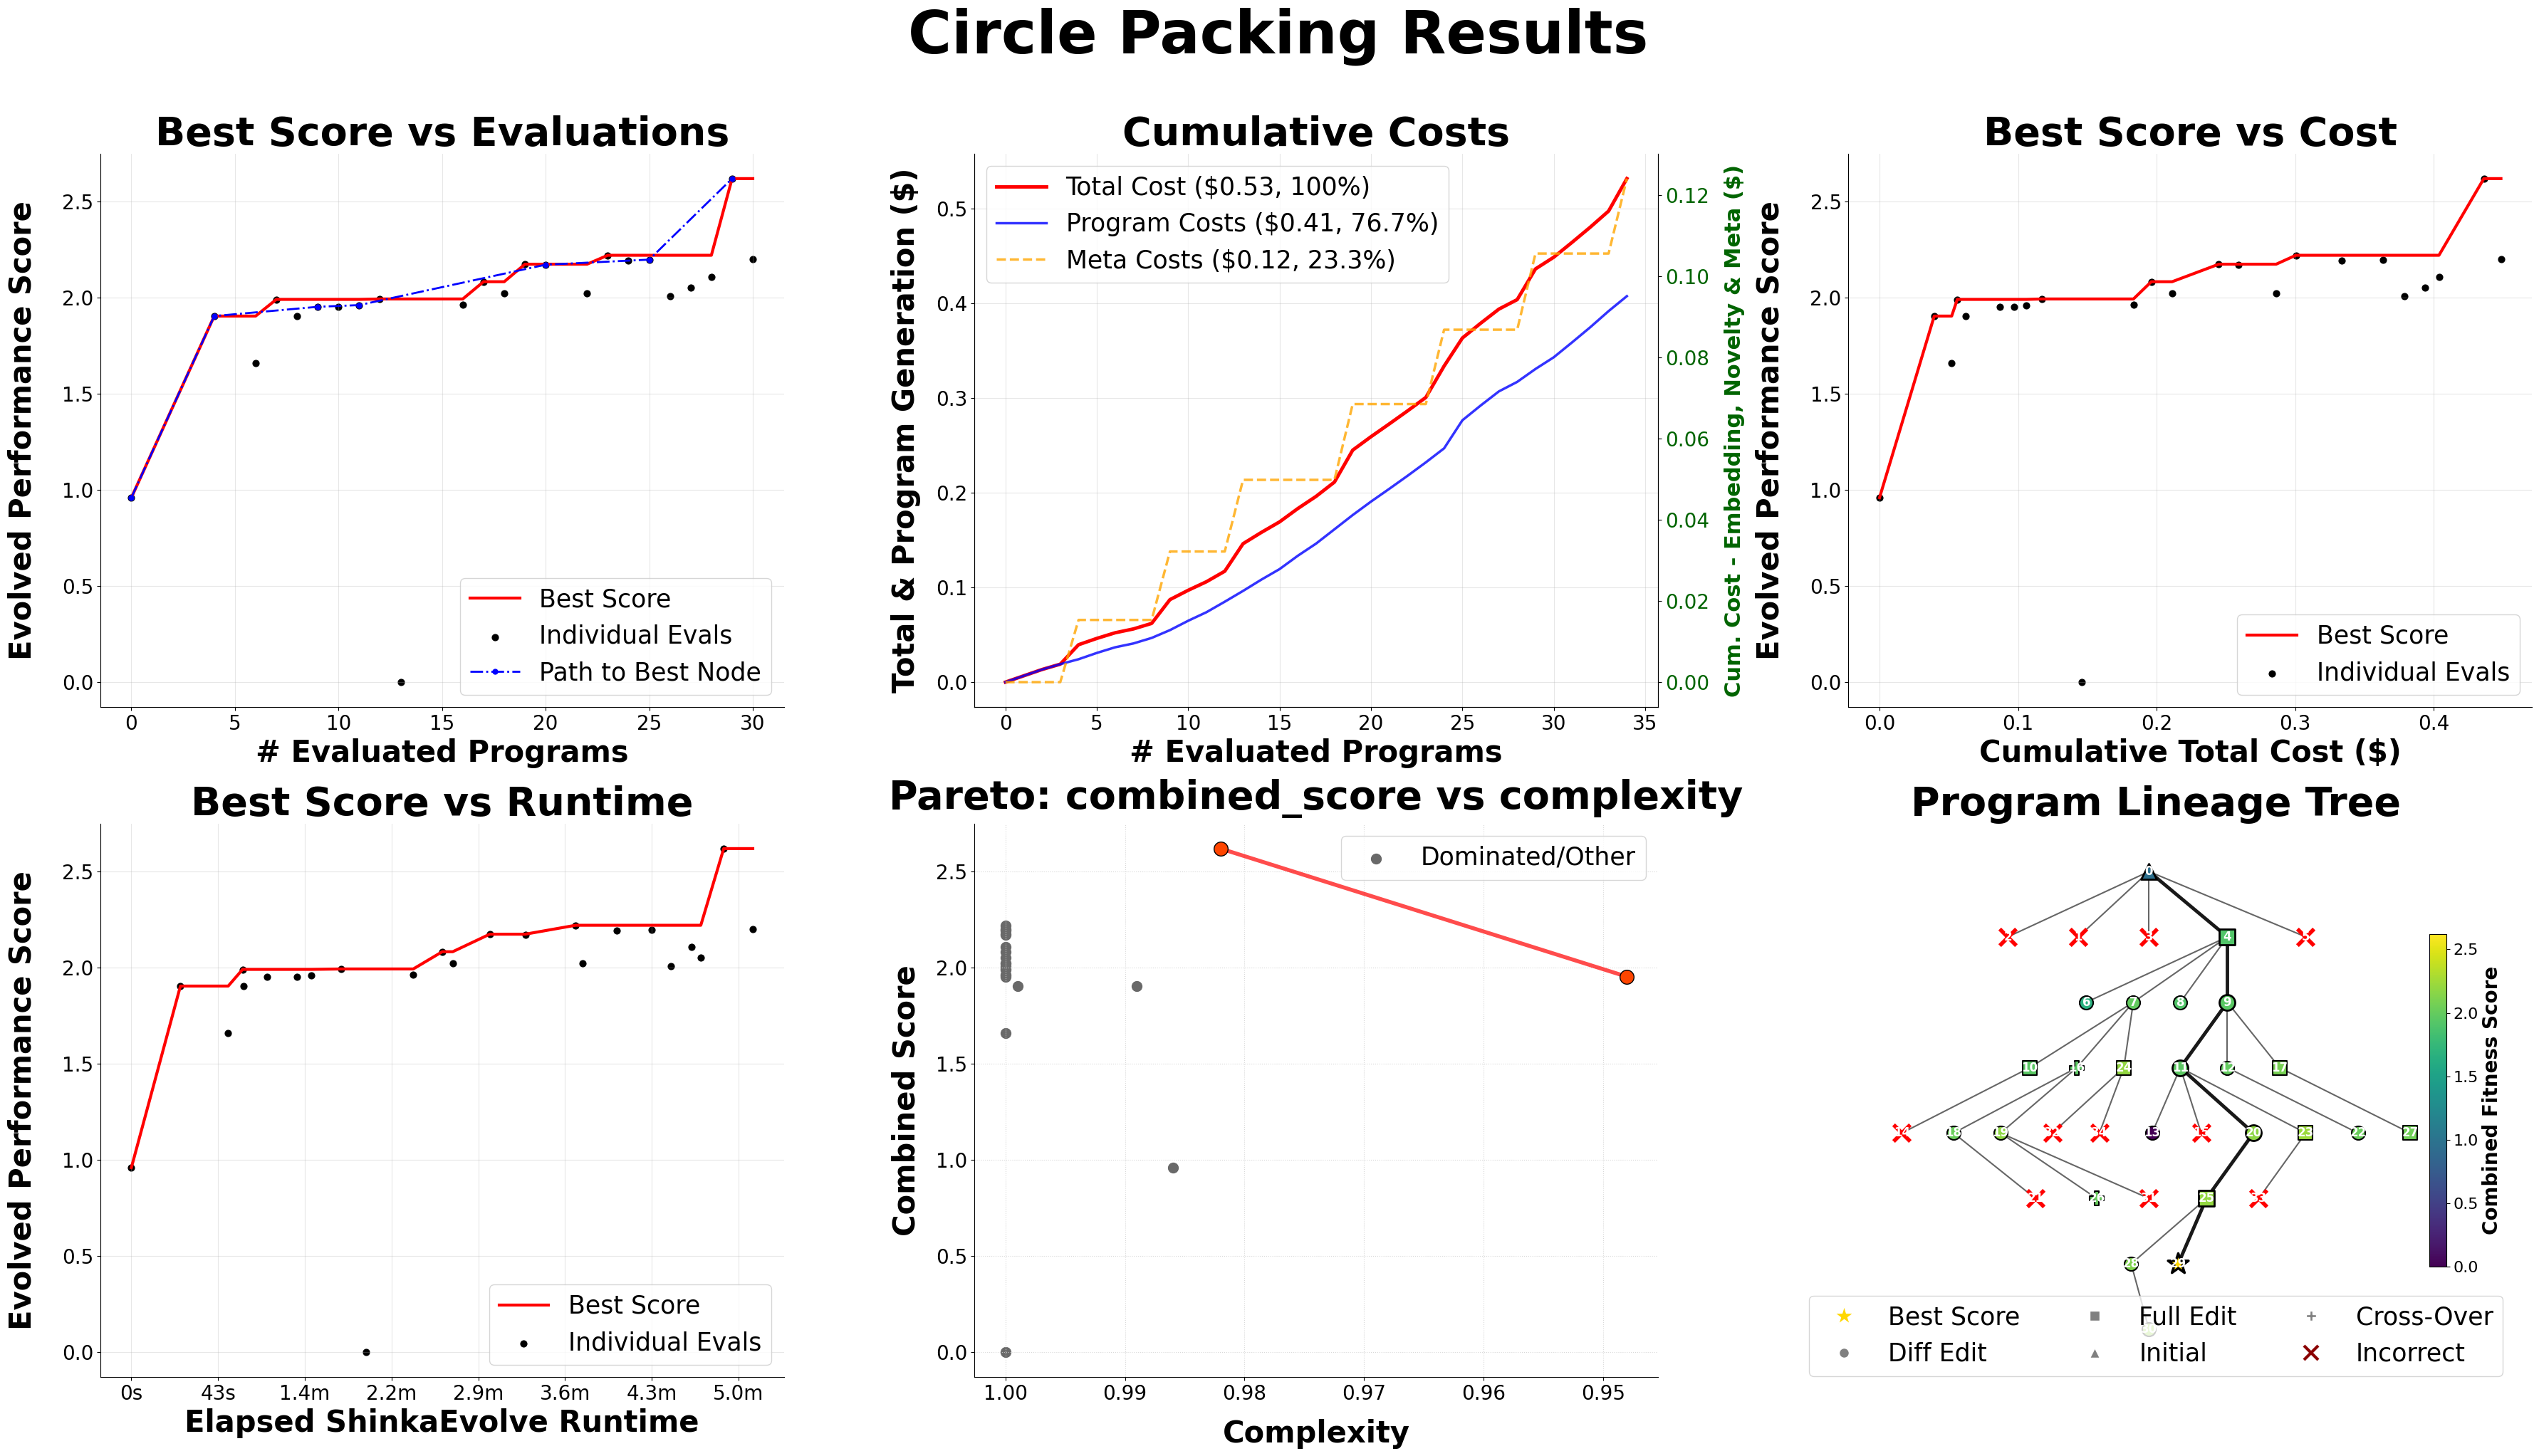

In [36]:
import matplotlib.pyplot as plt

from shinka.plots import plot_evals_performance
from shinka.plots import plot_costs
from shinka.plots import plot_cost_performance
from shinka.plots import plot_time_performance
from shinka.plots import plot_pareto_curve
from shinka.plots import plot_lineage_tree

if programs_df is None or programs_df.empty:
    raise ValueError(
        "No program data loaded. Update `path` in cell 0 to a valid results directory."
    )

fig, axs = plt.subplots(2, 3, figsize=(36, 20))
fig.suptitle("Circle Packing Results", fontsize=60, weight="bold", y=1.02)

plot_evals_performance(
    programs_df,
    title="Best Score vs Evaluations",
    fig=fig,
    ax=axs[0, 0],
    annotate=False,
    show_cost=False,
)

plot_costs(
    programs_df,
    title="Cumulative Costs",
    fig=fig,
    ax=axs[0, 1],
)

plot_cost_performance(
    programs_df,
    title="Best Score vs Cost",
    fig=fig,
    ax=axs[0, 2],
)

plot_time_performance(
    programs_df,
    title="Best Score vs Runtime",
    fig=fig,
    ax=axs[1, 0],
)

# Pick a Pareto pair that usually exists in Shinka results.
if "loc" in programs_df.columns:
    pareto_x, pareto_y = "loc", "combined_score"
    x_maximize, y_maximize = False, True
elif "complexity" in programs_df.columns:
    pareto_x, pareto_y = "complexity", "combined_score"
    x_maximize, y_maximize = False, True
elif "total_cost" in programs_df.columns:
    pareto_x, pareto_y = "total_cost", "combined_score"
    x_maximize, y_maximize = False, True
else:
    pareto_x, pareto_y = "generation", "combined_score"
    x_maximize, y_maximize = True, True

plot_pareto_curve(
    programs_df,
    x_variable=pareto_x,
    y_variable=pareto_y,
    x_maximize=x_maximize,
    y_maximize=y_maximize,
    title=f"Pareto: {pareto_y} vs {pareto_x}",
    fig=fig,
    ax=axs[1, 1],
    annotate=False,
)

plot_lineage_tree(
    programs_df,
    title="Program Lineage Tree",
    fig=fig,
    ax=axs[1, 2],
)

plt.tight_layout()
plt.show()
